# Hierarchical Tsetlin Machine for 20 Newsgroups document pairs

This notebook classifies pairs of complete 20 Newsgroups posts. A pair has label `Y=1` when both posts belong to the same category and `Y=0` otherwise.

## Requirements

- Python 3.10 or later
- NVIDIA GPU, NVIDIA driver, CUDA, and PyCUDA
- `numpy`, `scikit-learn`, `matplotlib`, `networkx`, and `PyHierarchicalTsetlinMachineCUDA`

```bash
python -m pip install numpy scikit-learn pycuda matplotlib networkx PyHierarchicalTsetlinMachineCUDA
```

In [1]:
from dataclasses import dataclass
from time import perf_counter
import numpy as np

## 1. Configuration

`categories=None` selects all 20 categories. The pair representation has `2 * features` binary inputs: words shared by both documents followed by words present in exactly one document.

In [2]:
@dataclass(frozen=True)
class Config:
    num_clauses: int
    threshold: int
    s: float
    epochs: int
    weighted_clauses: bool
    append_negated: bool
    boost_true_positive_feedback: int
    number_of_state_bits: int
    features: int
    number_of_alternatives: int
    number_of_concepts: int
    pair_encoding: str
    remove_stop_words: bool
    train_pairs: int
    test_pairs: int
    categories: tuple[str, ...] | None
    seed: int

# categories=None means all 20 Newsgroups categories.
CONFIG = Config(
    num_clauses=20,
    threshold=128,
    s=100,
    epochs=50,
    features=512,
    number_of_alternatives=64,
    number_of_concepts=2,
    weighted_clauses=False,
    append_negated=False,
    boost_true_positive_feedback=0,
    number_of_state_bits=10,
    pair_encoding='shared_different',
    remove_stop_words=True,
    train_pairs=20_000,
    test_pairs=5000,
    categories=None,
    seed=42,
)

## 2. Load and vectorize the dataset

The vocabulary is fitted on the training split only and then applied unchanged to the test split.

In [3]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

def load_split(subset, categories):
    data = fetch_20newsgroups(
        subset=subset,
        categories=categories,
        remove=('headers', 'footers', 'quotes'),
    )
    expected_categories = 20 if categories is None else len(categories)
    if len(data.target_names) != expected_categories:
        raise RuntimeError('The fetched category set does not match CONFIG.categories.')
    return tuple(data.data), np.asarray(data.target, dtype=np.int32), tuple(data.target_names)

train_documents, train_targets, target_names = load_split('train', CONFIG.categories)
test_documents, test_targets, test_target_names = load_split('test', CONFIG.categories)
assert target_names == test_target_names
print('Categories:', ', '.join(target_names))

vectorizer = CountVectorizer(
    binary=True,
    ngram_range=(1, 1),
    max_features=CONFIG.features,
    stop_words='english' if CONFIG.remove_stop_words else None,
)
train_X = vectorizer.fit_transform(train_documents).toarray().astype(np.uint32)
test_X = vectorizer.transform(test_documents).toarray().astype(np.uint32)

if train_X.shape[1] != CONFIG.features:
    raise RuntimeError(f'Expected {CONFIG.features} features, got {train_X.shape[1]}.')

# Remove posts that have no retained vocabulary word.
train_keep = train_X.any(axis=1)
test_keep = test_X.any(axis=1)
train_X, train_targets = train_X[train_keep], train_targets[train_keep]
test_X, test_targets = test_X[test_keep], test_targets[test_keep]
print(f'Kept {len(train_targets)} train and {len(test_targets)} test posts after vectorization.')

Categories: alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x, misc.forsale, rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey, sci.crypt, sci.electronics, sci.med, sci.space, soc.religion.christian, talk.politics.guns, talk.politics.mideast, talk.politics.misc, talk.religion.misc
Kept 10861 train and 7196 test posts after vectorization.


## 3. Create balanced document pairs

Each split contains an equal number of positive and negative pairs. Positive pairs contain two distinct documents from one category; negative pairs contain documents from different categories.

In [4]:
def sample_balanced_pairs(targets, number_of_pairs, seed):
    if number_of_pairs <= 0 or number_of_pairs % 2:
        raise ValueError('number_of_pairs must be positive and even.')

    targets = np.asarray(targets, dtype=np.int32)
    by_category = {category: np.flatnonzero(targets == category) for category in np.unique(targets)}
    positive_categories = np.asarray([c for c, indexes in by_category.items() if len(indexes) >= 2])
    categories = np.asarray(list(by_category))
    rng = np.random.default_rng(seed)
    half = number_of_pairs // 2
    left = np.empty(number_of_pairs, dtype=np.int32)
    right = np.empty(number_of_pairs, dtype=np.int32)
    labels = np.empty(number_of_pairs, dtype=np.uint32)

    for row in range(half):
        category = int(rng.choice(positive_categories))
        left[row], right[row] = rng.choice(by_category[category], size=2, replace=False)
        labels[row] = 1

    for row in range(half, number_of_pairs):
        left_category, right_category = rng.choice(categories, size=2, replace=False)
        left[row] = rng.choice(by_category[int(left_category)])
        right[row] = rng.choice(by_category[int(right_category)])
        labels[row] = 0

    swap = rng.random(number_of_pairs) < 0.5
    left[swap], right[swap] = right[swap].copy(), left[swap].copy()
    order = rng.permutation(number_of_pairs)
    return left[order], right[order], labels[order]

def make_pair_matrix(document_X, left, right, encoding):
    left_X, right_X = document_X[left], document_X[right]
    if encoding == 'concatenate':
        # Baseline: all words from document 1, then all from document 2.
        pair_X = np.hstack((left_X, right_X))
    elif encoding == 'shared_different':
        # Relation input: words in both posts, then words in exactly one.
        shared = np.bitwise_and(left_X, right_X)
        different = np.bitwise_xor(left_X, right_X)
        pair_X = np.hstack((shared, different))
    else:
        raise ValueError(f'Unknown pair encoding: {encoding}')
    return np.ascontiguousarray(pair_X, dtype=np.uint32)

train_left, train_right, train_y = sample_balanced_pairs(train_targets, CONFIG.train_pairs, CONFIG.seed)
test_left, test_right, test_y = sample_balanced_pairs(test_targets, CONFIG.test_pairs, CONFIG.seed + 1)

X_train = make_pair_matrix(train_X, train_left, train_right, CONFIG.pair_encoding)
X_test = make_pair_matrix(test_X, test_left, test_right, CONFIG.pair_encoding)

assert train_y.sum() == len(train_y) // 2
assert test_y.sum() == len(test_y) // 2
assert np.all((train_targets[train_left] == train_targets[train_right]) == train_y)
assert np.all((test_targets[test_left] == test_targets[test_right]) == test_y)
assert X_train.shape[1] == 2 * CONFIG.features
assert X_test.shape[1] == 2 * CONFIG.features
assert np.all((X_train == 0) | (X_train == 1))
assert np.all((X_test == 0) | (X_test == 1))
print(f'Pair encoding: {CONFIG.pair_encoding}')
print('Train:', X_train.shape, 'Test:', X_test.shape)

Pair encoding: shared_different
Train: (20000, 1024) Test: (5000, 1024)


## 4. HTM model


In [5]:
# MultiClassTsetlinMachine uses NumPy's global RNG internally when it
# balances and shuffles one-vs-rest training examples.
np.random.seed(CONFIG.seed)
import pycuda.driver as cuda
cuda.init()
if cuda.Device.count() < 1:
    raise RuntimeError('No CUDA-capable GPU found by PyCUDA.')

from PyHierarchicalTsetlinMachineCUDA.tm import (
    AND_ALTERNATIVES,
    AND_GROUP,
    OR_ALTERNATIVES,
    MultiClassTsetlinMachine,
)

hierarchy = (
    (AND_GROUP, X_train.shape[1]),
    (OR_ALTERNATIVES, CONFIG.number_of_alternatives),
    (AND_ALTERNATIVES, CONFIG.number_of_concepts),

)
model = MultiClassTsetlinMachine(
    CONFIG.num_clauses,
    CONFIG.threshold,
    CONFIG.s,
    weighted_clauses=CONFIG.weighted_clauses,
    hierarchy_structure=hierarchy,
    number_of_state_bits=CONFIG.number_of_state_bits,
    append_negated=CONFIG.append_negated,
    boost_true_positive_feedback=CONFIG.boost_true_positive_feedback,
    seed=CONFIG.seed,
)
print('CUDA device:', cuda.Device(0).name())
print('Hierarchy:', hierarchy)

CUDA device: Tesla V100-SXM3-32GB
Hierarchy: ((0, 1024), (3, 64), (1, 2))


## 5. Training and evaluation

In [6]:
for epoch in range(CONFIG.epochs):
    start = perf_counter()
    model.fit(X_train, train_y)
    train_seconds = perf_counter() - start

    start = perf_counter()
    test_scores = model.score(X_test)
    test_predictions = np.argmax(test_scores, axis=0).astype(np.uint32)
    test_seconds = perf_counter() - start
    train_predictions = model.predict(X_train)

    train_accuracy = 100 * (train_predictions == train_y).mean()
    test_accuracy = 100 * (test_predictions == test_y).mean()
    print(
        f'Epoch {epoch + 1}/{CONFIG.epochs} | '
        f'train accuracy: {train_accuracy:.2f}% | '
        f'test accuracy: {test_accuracy:.2f}% | '
        f'test Y=1 predictions: {100 * test_predictions.mean():.1f}% | '
        f'train: {train_seconds:.2f}s | test: {test_seconds:.2f}s'
    )

/home/coder/htm-language-learning/.venv/lib/python3.12/site-packages/PyHierarchicalTsetlinMachineCUDA/tm.py:150: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod_update = SourceModule(parameters + kernels.code_header + kernels.code_update, no_extern_c=True)
/home/coder/htm-language-learning/.venv/lib/python3.12/site-packages/PyHierarchicalTsetlinMachineCUDA/tm.py:189: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod_clauses = SourceModule(parameters + kernels.code_clauses, no_extern_c=True)


Epoch 1/50 | train accuracy: 51.59% | test accuracy: 51.20% | test Y=1 predictions: 7.4% | train: 7.59s | test: 0.55s
Epoch 2/50 | train accuracy: 53.59% | test accuracy: 52.72% | test Y=1 predictions: 76.6% | train: 4.67s | test: 0.55s
Epoch 3/50 | train accuracy: 52.06% | test accuracy: 51.08% | test Y=1 predictions: 1.8% | train: 4.71s | test: 0.57s
Epoch 4/50 | train accuracy: 50.38% | test accuracy: 50.08% | test Y=1 predictions: 99.6% | train: 4.68s | test: 0.55s
Epoch 5/50 | train accuracy: 57.07% | test accuracy: 53.56% | test Y=1 predictions: 23.8% | train: 4.70s | test: 0.55s
Epoch 6/50 | train accuracy: 56.53% | test accuracy: 55.32% | test Y=1 predictions: 14.4% | train: 4.69s | test: 0.55s
Epoch 7/50 | train accuracy: 55.92% | test accuracy: 52.82% | test Y=1 predictions: 84.2% | train: 4.72s | test: 0.65s
Epoch 8/50 | train accuracy: 55.60% | test accuracy: 54.24% | test Y=1 predictions: 7.2% | train: 4.71s | test: 0.55s
Epoch 9/50 | train accuracy: 57.12% | test accuracy

## 6. Visualize learned HTM rules

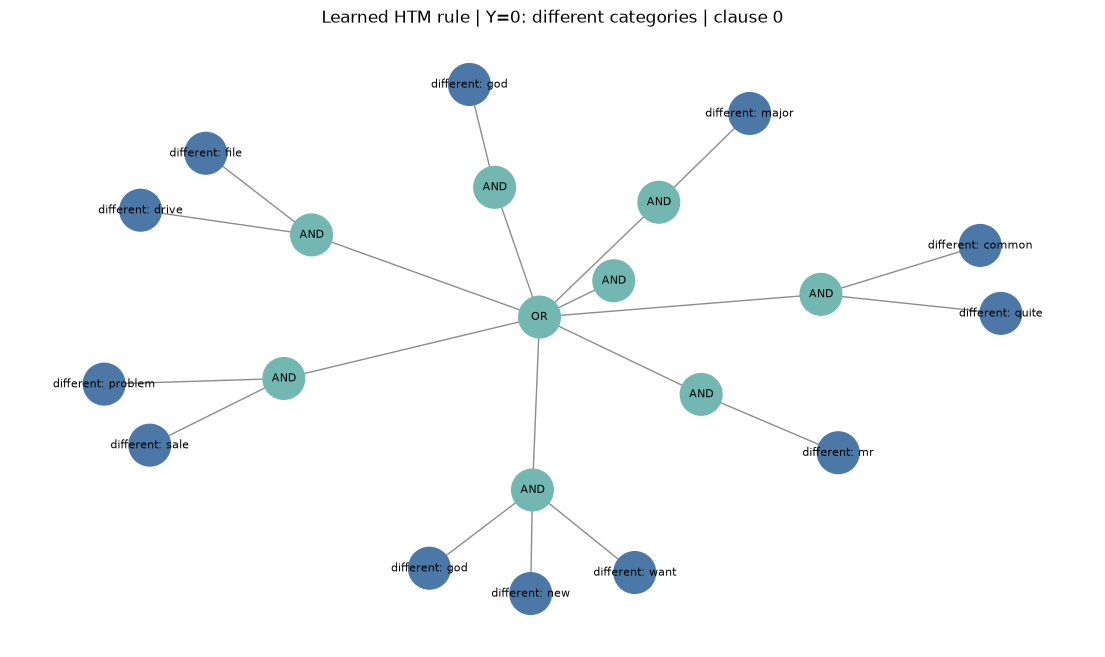

Visible included literals (12):
different: drive, different: file, different: god, different: common, different: quite, different: problem, different: sale, different: god, different: new, different: want, different: mr, different: major


In [ ]:
VISUAL_CLASS = 0       # 1 = samme kategori, 0 = forskjellig kategori
VISUAL_CLAUSE = 0   
MAX_LITERAL_NODES = 12 # begrenser grafen

def plot_rule():
    import matplotlib.pyplot as plt
    import networkx as nx
    from PyHierarchicalTsetlinMachineCUDA.utils import clause_to_nx

    if VISUAL_CLASS not in (0, 1):
        raise ValueError('VISUAL_CLASS must be 0 or 1.')
    if not 0 <= VISUAL_CLAUSE < CONFIG.num_clauses:
        raise ValueError('VISUAL_CLAUSE is outside the available clauses.')

    # Name each input bit so that the graph contains readable words.
    words = list(vectorizer.get_feature_names_out())
    if CONFIG.pair_encoding == 'shared_different':
        feature_names = ([f'shared: {word}' for word in words] +
                         [f'different: {word}' for word in words])
    else:
        feature_names = ([f'left: {word}' for word in words] +
                         [f'right: {word}' for word in words])

    binary_tm = model.tms[VISUAL_CLASS]
    graph = clause_to_nx(
        binary_tm,
        VISUAL_CLAUSE,
        feature_names=feature_names,
        node_type_labels={AND_GROUP: 'AND', OR_ALTERNATIVES: 'OR', AND_ALTERNATIVES: 'AND'},
    )

    # Keep paths from the root to included word literals only.
    root = (binary_tm.depth, 0)
    literal_nodes = sorted(node for node in graph if node[0] == 0)[:MAX_LITERAL_NODES]
    if not literal_nodes:
        raise RuntimeError('This clause contains no included word literals yet.')
    visible_nodes = {root}
    for literal in literal_nodes:
        visible_nodes.update(nx.shortest_path(graph, root, literal))
    rule_graph = graph.subgraph(visible_nodes).copy()

    labels = nx.get_node_attributes(rule_graph, 'label')
    pos = nx.spring_layout(rule_graph, seed=CONFIG.seed)
    colors = ['#4c78a8' if node[0] == 0 else '#72b7b2' for node in rule_graph]
    plt.figure(figsize=(14, 8))
    nx.draw_networkx_edges(rule_graph, pos, alpha=0.45)
    nx.draw_networkx_nodes(rule_graph, pos, node_color=colors, node_size=900)
    nx.draw_networkx_labels(rule_graph, pos, labels=labels, font_size=8)
    class_name = 'Y=1: same category' if VISUAL_CLASS == 1 else 'Y=0: different categories'
    plt.title(f'Learned HTM rule | {class_name} | clause {VISUAL_CLAUSE}')
    plt.axis('off')
    plt.show()

    literals = [labels[node] for node in literal_nodes]
    print(f'Visible included literals ({len(literals)}):')
    print(', '.join(literals))

plot_rule()